<a href="https://colab.research.google.com/github/danielhacobian/probing-VLMs/blob/initial-release/notebooks/umaze_layerwise_motion_probe_paper_lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Where does UMaze physics become readable?

This notebook reproduces and strengthens the repository's UMaze linear-probe methodology. It asks **which physical variables can be recovered with a simple linear map, from which internal tensor, and at which model layer**. The variables are 2-D position, 2-D velocity, 2-D acceleration, speed, heading, acceleration magnitude, and acceleration direction.

The key distinction is temporal context:

- **DINO is a per-frame visual encoder.** At layer $\ell$, it produces a token tensor for one image. We probe its CLS token, the mean of its patch tokens, and the projected aggregate. Position is decoded from one frame's feature $h_t^\ell$. Motion is decoded primarily from the change between frames: $\Delta h_t^\ell$ for velocity and $\Delta^2 h_t^\ell$ for acceleration.
- **The predictor is temporally contextual.** It receives visual tokens together with action/proprioception and causal history. We probe the mean predictor visual-token activation at each predictor block. Because this activation has already mixed temporal and action context, its per-slot feature may legitimately contain motion information.

The model weights are frozen: only a ridge-linear decoder is fitted. Therefore, **readable** means that the variable is arranged accessibly enough for a linear map to recover it on held-out data. It does **not** mean the variable is stored in a single neuron, uniquely represented, or causally used by the planner.

## One-click Colab setup

This version uses **all 2,000 complete trajectories** in the public OSF UMaze dataset. It selects one deterministic four-frame window from every trajectory, so the probe receives 2,000 windows from 2,000 unique episodes rather than repeatedly sampling a smaller subset.

The straightening-OFF model is the paper-matched OSF seed-0 checkpoint trained with encoder/projector learning rate `1e-6`. The straightening-ON model uses `aggcos1e-1` and learning rate `1e-5`, following the learning-rate convention reported in the Temporal Straightening paper. The same windows, labels, splits, probes, and metrics are used for both models. Because the learning rates differ, ON-minus-OFF compares the two paper configurations rather than isolating the straightening term alone.

Both frozen checkpoints and their provenance sidecars are verified against SHA-256 manifests and fetched from the pinned historical checkpoint source. The notebook clones that branch, reconstructs the checkpoint files locally, and downloads only the public trajectory dataset from OSF. **Google Drive, private uploads, and saved secrets are not required.** A GPU runtime is strongly recommended because the notebook extracts fresh activations from both checkpoints.




In [1]:
import hashlib, os, subprocess, sys, urllib.request
from pathlib import Path

REPO_URL = "https://github.com/danielhacobian/probing-VLMs.git"
REPO_BRANCH = "initial-release"
COLAB_REPO = Path("/content/probing-VLMs")

try:
    import google.colab  # type: ignore  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

if IN_COLAB:
    if not (COLAB_REPO / ".git").exists():
        subprocess.run([
            "git", "clone", "--branch", REPO_BRANCH, "--single-branch",
            REPO_URL, str(COLAB_REPO),
        ], check=True)
    else:
        subprocess.run([
            "git", "-C", str(COLAB_REPO), "fetch", "origin", REPO_BRANCH,
        ], check=True)
        subprocess.run([
            "git", "-C", str(COLAB_REPO), "checkout", "--detach", "FETCH_HEAD",
        ], check=True)
    os.chdir(COLAB_REPO)
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "decord", "einops", "omegaconf", "hydra-core==1.3.2",
    ], check=True)

os.environ.setdefault("UMAZE_PROBE_OUTPUT", "/content/umaze_probe_results")
print({"in_colab": IN_COLAB, "repo": str(Path.cwd()), "window_mode": "all_2000_trajectories"})


{'in_colab': True, 'repo': '/content/probing-VLMs', 'window_mode': 'all_2000_trajectories'}


## Experimental design

For a layer representation $h_t^\ell$:

$$p_t=(x_t,y_t),\qquad v_t=\\frac{p_{t+1}-p_t}{\Delta t},\qquad a_t=\\frac{v_{t+1}-v_t}{\Delta t}$$

Let a cached representation have shape `[window, time, feature] = [N,T,D]`. For four sampled frames, a frame probe sees $N\times T$ rows of $D$ features, a first-difference probe sees $N\times(T-1)$ rows, and a second-difference probe sees $N\times(T-2)$ rows. The probe never receives pixels, model parameters, future labels, or explicit XY coordinates (except in the separate position-only control).

Primary feature/target pairs:

| Family | Tensor probed | Position target | Velocity target | Acceleration target |
|---|---|---|---|---|
| DINO | CLS, mean patch tokens, or projected aggregate at block $\ell$ | $h_t^\ell \rightarrow (x_t,y_t)$ | $h_{t+1}^\ell-h_t^\ell \rightarrow (p_{t+1}-p_t)/\Delta t$ | $h_{t+2}^\ell-2h_{t+1}^\ell+h_t^\ell \rightarrow (v_{t+1}-v_t)/\Delta t$ |
| Predictor | mean contextual visual tokens at block $\ell$ | $h_t^\ell \rightarrow (x_t,y_t)$ | $h_t^\ell \rightarrow (v_{x,t},v_{y,t})$ | $h_t^\ell \rightarrow (a_{x,t},a_{y,t})$ |

Every probe standardizes features using **training-set statistics only** and fits ridge regression with $\lambda=10$. A single probe is fitted independently for each `(family, layer, representation kind, target, feature construction, split)` combination. We compare an episode-held-out split with a spatially blocked split and include shuffled-label, position-only, and position-residualized controls.

In [2]:
from pathlib import Path
import csv, json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.umaze_probe_walkthrough import (
    align_representation, bootstrap_metric_ci, build_motion_targets,
    direction_scores, episode_group_split, episode_group_train_val_test_split,
    fit_probe, fit_probe_grouped, group_flat_predictions_by_window,
    grouped_metric, grouped_regression_summary,
    load_activation_cache, select_then_test_representations,
    trajectory_bootstrap_metric_ci,
    mask_slow_directions, readability_onset, regression_scores, residualize_against_position,
    save_activation_cache, shuffled_label_score, spatial_holdout_split,
)

plt.style.use("seaborn-v0_8-whitegrid")

def write_rows(path, rows):
    if not rows:
        return
    fieldnames = list(dict.fromkeys(key for row in rows for key in row))
    with Path(path).open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader(); writer.writerows(rows)

def show_rows(rows, columns=None, limit=20):
    rows = list(rows)[:limit]
    if not rows:
        print("(no rows)"); return
    columns = columns or list(rows[0])
    widths = {
        key: min(42, max(len(key), *(len(f"{row.get(key, '')}") for row in rows)))
        for key in columns
    }
    print(" | ".join(key.ljust(widths[key]) for key in columns))
    print("-+-".join("-" * widths[key] for key in columns))
    for row in rows:
        print(" | ".join(f"{row.get(key, '')}"[:widths[key]].ljust(widths[key]) for key in columns))

def grouped(rows, keys):
    result = {}
    for row in rows:
        key = tuple(row[name] for name in keys)
        result.setdefault(key, []).append(row)
    return result

def configured_path(environment_key, *candidates):
    if os.environ.get(environment_key):
        return Path(os.environ[environment_key]).expanduser()
    for candidate in candidates:
        candidate = Path(candidate).expanduser()
        if candidate.exists():
            return candidate
    return Path(candidates[0]).expanduser()
SEED = 0
RIDGE = 10.0
MAX_TRAJECTORIES = 2000
WINDOWS_PER_TRAJECTORY = 1
MAX_WINDOWS = MAX_TRAJECTORIES
NUM_FRAMES = 4
FRAME_SKIP = 5
STEP_DT = 1.0  # set to the environment seconds-per-step if physical units are needed
BATCH_SIZE = 8

WORKSPACE_ROOT = ROOT.resolve().parent
CHECKPOINT = configured_path(
    "UMAZE_CHECKPOINT",
    ROOT / "artifacts/checkpoints/umaze_paper_protocol_on_off/off/model_20.pth",
    WORKSPACE_ROOT / "reference/r0_direction_only/checkpoints/model_20.pth",
)
DATA_DIR = configured_path(
    "UMAZE_DATA_DIR",
    Path.home() / "data/point_maze",
    WORKSPACE_ROOT / "data/point_maze",
)
OUTPUT_DIR = Path(os.environ.get("UMAZE_PROBE_OUTPUT", ROOT / "baseline_artifacts/analysis/umaze_probe_walkthrough"))
CACHE = OUTPUT_DIR / f"activation_cache_{MAX_WINDOWS}_off.npz"
DEVICE = os.environ.get("UMAZE_DEVICE", "cuda:0")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print({"trajectories": MAX_TRAJECTORIES, "windows_per_trajectory": WINDOWS_PER_TRAJECTORY, "cache": str(CACHE), "device": DEVICE})

{'trajectories': 2000, 'windows_per_trajectory': 1, 'cache': '/content/umaze_probe_results/activation_cache_2000_off.npz', 'device': 'cuda:0'}


## 1. Collect intermediate activations from all 2,000 trajectories

The OSF archive contains 2,000 complete trajectories, numbered 0 through 1,999. We choose one valid `(episode, start frame)` window from each trajectory using the fixed seed. This maximizes independent trajectory coverage while keeping the Colab workload practical; enumerating every valid start would create about 170,000 overlapping windows.

The cache stores states, actions, identifiers, and frozen intermediate tensors. Representation names have the form `family/layer/kind`:

- `dino/L/cls`: shape `[2000,T,D_dino]`.
- `dino/L/pooled_patches`: shape `[2000,T,D_dino]`.
- `dino/L/projected_aggregate`: shape `[2000,T,D_proj]`.
- `predictor/L/pooled_visual`: shape `[2000,T,D_pred]`.

The cache filename includes `2000` and is accepted only if it contains exactly one window from every episode. Older 128- or 512-window caches cannot be reused accidentally.


In [3]:
import random
import zipfile
import torch
from datasets.img_transforms import default_transform
from datasets.point_maze_dset import PointMazeDataset
from scripts.activation_extraction import collect_activations, load_checkpoint

# Both frozen paper-protocol checkpoints and their provenance sidecars are
# described by repository manifests and restored from pinned public artifacts. No Google Drive mount or private file is needed.
CHECKPOINT_ROOT = ROOT / "artifacts/checkpoints/umaze_paper_protocol_on_off"
RESTORE_SCRIPT = CHECKPOINT_ROOT / "restore_checkpoints.sh"
MATCHED_CHECKPOINTS = {
    condition: CHECKPOINT_ROOT / condition / "model_20.pth"
    for condition in ("off", "on")
}
MATCHED_ASSETS = {
    "off": {
        "checkpoint_sha256": "6f864080cd6bef3b818fdeec52459208780ba8f217b6153d359eafb93000ba98",
        "straighten": False,
        "encoder_lr": 1e-6,
        "source": "paper-matched OSF seed-0 run; checkpoint fetched from pinned historical GitHub source",
        "config_path": str(CHECKPOINT_ROOT / "off/hydra.yaml"),
        "config_provenance": "reconstructed sidecar; see checkpoint README",
    },
    "on": {
        "checkpoint_sha256": "b41f3eabffe6e24585deaec2d2b6afb2f09cf3b840d905958493187e64ad7156",
        "straighten": "aggcos1e-1",
        "encoder_lr": 1e-5,
        "source": "paper straightening-ON run; checkpoint fetched from pinned historical GitHub source",
        "config_path": str(CHECKPOINT_ROOT / "on/hydra.yaml"),
        "config_provenance": "reconstructed sidecar; see checkpoint README",
    },
}

needs_restore = any(
    not path.exists() or sha256(path) != MATCHED_ASSETS[condition]["checkpoint_sha256"]
    for condition, path in MATCHED_CHECKPOINTS.items()
)
if needs_restore:
    subprocess.run(["bash", str(RESTORE_SCRIPT)], check=True)
for condition, checkpoint in MATCHED_CHECKPOINTS.items():
    assert sha256(checkpoint) == MATCHED_ASSETS[condition]["checkpoint_sha256"]

MATCHED_ASSET_DIR = Path("/content/umaze_matched_probe_assets")
MATCHED_ASSET_DIR.mkdir(parents=True, exist_ok=True)
MATCHED_DATA_ARCHIVE = MATCHED_ASSET_DIR / "point_maze.zip"
MATCHED_DATA_URL = "https://files.us.osf.io/v1/resources/bmw48/providers/osfstorage/678ac918567274d368282c6d"
MATCHED_DATA_SHA256 = "6c48ccf22c90b9af8dcf0e2cd70849aec8dd8e214ac5f1f09552bf8bc9494acc"
if not MATCHED_DATA_ARCHIVE.exists() or sha256(MATCHED_DATA_ARCHIVE) != MATCHED_DATA_SHA256:
    print("Downloading the public UMaze dataset archive from OSF...")
    urllib.request.urlretrieve(MATCHED_DATA_URL, MATCHED_DATA_ARCHIVE)
assert sha256(MATCHED_DATA_ARCHIVE) == MATCHED_DATA_SHA256

DATA_DIR = Path("/content/data/point_maze")
with zipfile.ZipFile(MATCHED_DATA_ARCHIVE) as bundle:
    names = bundle.namelist()
    states_name = next(name for name in names if name.endswith("/states.pth"))
    archive_prefix = states_name[:-len("states.pth")]
    for relative_name in ("states.pth", "actions.pth", "seq_lengths.pth"):
        target = DATA_DIR / relative_name
        if not target.exists():
            target.parent.mkdir(parents=True, exist_ok=True)
            with bundle.open(archive_prefix + relative_name) as source, target.open("wb") as sink:
                sink.write(source.read())

dataset = PointMazeDataset(
    data_path=str(DATA_DIR), transform=default_transform(224),
    normalize_action=True, use_frame_files=False,
)

# Select one deterministic valid start from every trajectory: 2,000 windows
# from 2,000 unique episodes, with no episode repeated.
rng = random.Random(SEED)
choices = []
for episode, length in enumerate(dataset.seq_lengths.tolist()):
    max_start = int(length) - 1 - FRAME_SKIP * (NUM_FRAMES - 1)
    if max_start >= 0:
        choices.append((episode, rng.randint(0, max_start)))
choices = np.asarray(choices, dtype=np.int64)
assert len(dataset) == MAX_TRAJECTORIES == 2000
assert choices.shape == (MAX_TRAJECTORIES, 2), choices.shape
assert len(set(choices[:, 0])) == MAX_TRAJECTORIES

with zipfile.ZipFile(MATCHED_DATA_ARCHIVE) as bundle:
    for episode in sorted(set(choices[:, 0])):
        relative_name = f"obses/episode_{int(episode):03d}.pth"
        target = DATA_DIR / relative_name
        if not target.exists():
            target.parent.mkdir(parents=True, exist_ok=True)
            with bundle.open(archive_prefix + relative_name) as source, target.open("wb") as sink:
                sink.write(source.read())

CHECKPOINT = MATCHED_CHECKPOINTS["off"]
CACHE = OUTPUT_DIR / f"activation_cache_{MAX_WINDOWS}_off_paper_lr1e6_6f864080.npz"
cache_is_valid = False
if CACHE.exists():
    representations, states, actions, cached_choices, cache_metadata = load_activation_cache(CACHE)
    cache_is_valid = np.array_equal(cached_choices, choices)
    if cache_is_valid:
        choices = np.asarray(cached_choices)
        print(f"Loaded {len(representations)} representations from {CACHE}")
    else:
        print(f"Ignoring stale cache with non-matching windows: {CACHE}")

if not cache_is_valid:
    device = torch.device(DEVICE)
    modules = load_checkpoint(CHECKPOINT, device)
    representations, states, actions = collect_activations(
        modules, dataset, choices, BATCH_SIZE, FRAME_SKIP, NUM_FRAMES, device,
        include_kinds={"cls", "pooled_patches", "projected_aggregate", "pooled_visual"},
    )
    cache_metadata = {
        "condition": "off", "checkpoint": str(CHECKPOINT),
        "straighten": MATCHED_ASSETS["off"]["straighten"],
        "encoder_lr": MATCHED_ASSETS["off"]["encoder_lr"],
        "checkpoint_sha256": MATCHED_ASSETS["off"]["checkpoint_sha256"],
        "data_dir": str(DATA_DIR), "seed": SEED,
        "num_windows": len(choices), "num_frames": NUM_FRAMES,
        "frameskip": FRAME_SKIP, "ridge": RIDGE,
    }
    save_activation_cache(CACHE, representations, states, actions, choices, cache_metadata)
    del modules
    torch.cuda.empty_cache()
    print(f"Saved all-2000-trajectory OFF activation cache to {CACHE}")

assert len(choices) == MAX_TRAJECTORIES
assert len(set(choices[:, 0])) == MAX_TRAJECTORIES
inventory = [
    {"representation": name, "shape": str(value.shape), "size_mb": value.nbytes / 2**20}
    for name, value in sorted(representations.items())
]
show_rows(inventory)
print({
    "complete_trajectories": len(set(choices[:, 0])),
    "windows": len(choices),
    "checkpoint": str(CHECKPOINT),
    "checkpoint_source": "verified historical artifact",
    "cache": str(CACHE),
})


Loaded 2000 rollouts
Downloading: "https://github.com/facebookresearch/dinov2/zipball/81b2b6419385" to /root/.cache/torch/hub/81b2b6419385.zip


/root/.cache/torch/hub/facebookresearch_dinov2_81b2b6419385/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_81b2b6419385/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_81b2b6419385/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 124MB/s]


Saved all-2000-trajectory OFF activation cache to /content/umaze_probe_results/activation_cache_2000_off_paper_lr1e6_6f864080.npz
representation              | shape          | size_mb 
----------------------------+----------------+---------
dino/0/cls                  | (2000, 4, 384) | 11.71875
dino/0/pooled_patches       | (2000, 4, 384) | 11.71875
dino/0/projected_aggregate  | (2000, 4, 128) | 3.90625 
dino/1/cls                  | (2000, 4, 384) | 11.71875
dino/1/pooled_patches       | (2000, 4, 384) | 11.71875
dino/1/projected_aggregate  | (2000, 4, 128) | 3.90625 
dino/10/cls                 | (2000, 4, 384) | 11.71875
dino/10/pooled_patches      | (2000, 4, 384) | 11.71875
dino/10/projected_aggregate | (2000, 4, 128) | 3.90625 
dino/11/cls                 | (2000, 4, 384) | 11.71875
dino/11/pooled_patches      | (2000, 4, 384) | 11.71875
dino/11/projected_aggregate | (2000, 4, 128) | 3.90625 
dino/2/cls                  | (2000, 4, 384) | 11.71875
dino/2/pooled_patches       | 

## 2. Construct physical targets and inspect shortcut risk

Position comes from `state[..., :2] = (x,y)`. Instantaneous velocity uses `state[..., 2:4] = (v_x,v_y)` when present. For a DINO first-difference feature spanning frames $t$ and $t+1$, the label is the matching displacement velocity $(p_{t+1}-p_t)/\Delta t$. Acceleration is the matching finite difference of velocity. With `FRAME_SKIP=5` and `STEP_DT=1`, adjacent cached frames are separated by $\Delta t=5$ environment steps; change `STEP_DT` if one simulator step corresponds to a known number of seconds.

Before fitting a model probe, inspect whether speed and acceleration already correlate with maze location. Strong spatial structure is exactly the shortcut a single-frame DINO probe could exploit.

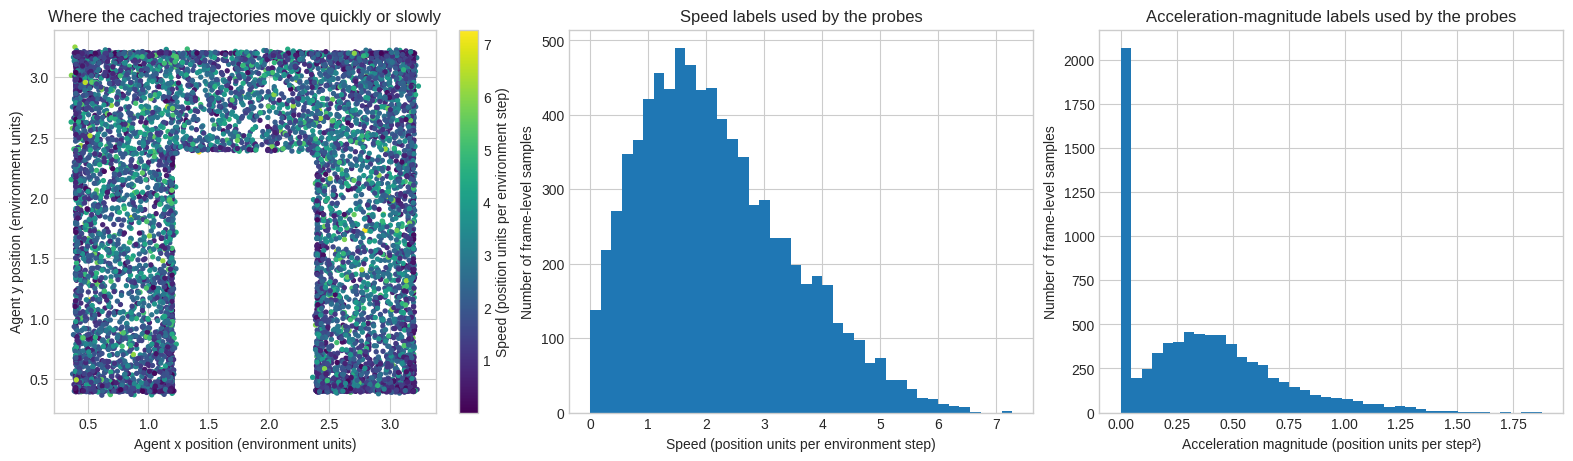

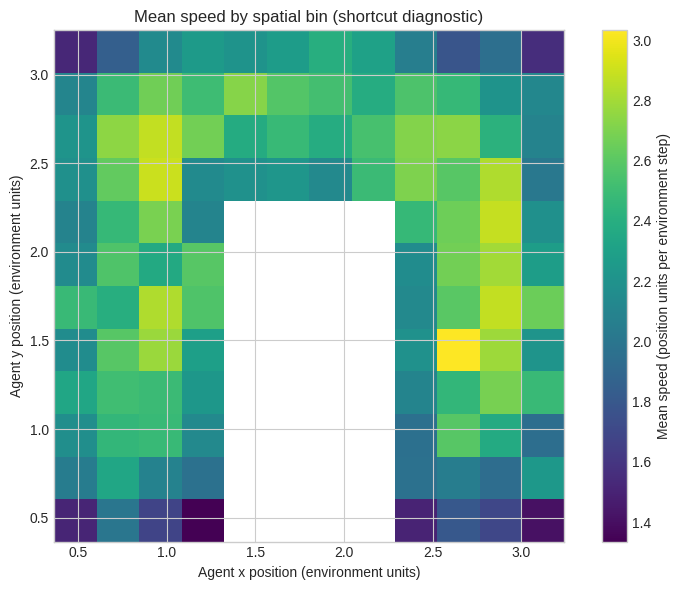

In [4]:
targets = build_motion_targets(states, FRAME_SKIP, STEP_DT)
position = targets["position"].reshape(-1, 2)
speed = targets["speed"].reshape(-1)
acceleration_magnitude = targets["acceleration_magnitude"].reshape(-1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
coverage = axes[0].scatter(position[:, 0], position[:, 1], c=speed, s=8, cmap="viridis")
axes[0].set(
    title="Where the cached trajectories move quickly or slowly",
    xlabel="Agent x position (environment units)",
    ylabel="Agent y position (environment units)", aspect="equal",
)
fig.colorbar(coverage, ax=axes[0], label="Speed (position units per environment step)")
axes[1].hist(speed, bins=40)
axes[1].set(
    title="Speed labels used by the probes",
    xlabel="Speed (position units per environment step)",
    ylabel="Number of frame-level samples",
)
axes[2].hist(acceleration_magnitude[np.isfinite(acceleration_magnitude)], bins=40)
axes[2].set(
    title="Acceleration-magnitude labels used by the probes",
    xlabel="Acceleration magnitude (position units per step²)",
    ylabel="Number of frame-level samples",
)
fig.savefig(OUTPUT_DIR / "dataset_motion_overview.png", dpi=180)
plt.show()

weighted, x_edges, y_edges = np.histogram2d(position[:, 0], position[:, 1], bins=12, weights=speed)
counts, _, _ = np.histogram2d(position[:, 0], position[:, 1], bins=[x_edges, y_edges])
speed_map = np.divide(weighted, counts, out=np.full_like(weighted, np.nan), where=counts > 0)
plt.figure(figsize=(8, 6)); plt.imshow(
    speed_map.T, origin="lower", cmap="viridis", aspect="equal",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
)
plt.colorbar(label="Mean speed (position units per environment step)")
plt.xlabel("Agent x position (environment units)")
plt.ylabel("Agent y position (environment units)")
plt.title("Mean speed by spatial bin (shortcut diagnostic)")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "speed_by_position.png", dpi=180); plt.show()

## 3. Leakage-resistant evaluation splits

- **Episode validation:** complete trajectories are assigned to training, validation, or a locked test partition. Layer and readout selection uses validation trajectories only.
- **Spatial validation:** the upper 20% of development-only window-anchor Y positions is validation-only, with a buffer band removed from training.

All exploratory layer curves use only training and validation trajectories. The locked test trajectories are evaluated once, after representation selection, in the confirmatory section.

{'episode_validation': (1200, 400), 'spatial_validation': (1175, 320)}
Spatial split: {'boundary': 2.955403232574463, 'buffer': 0.1438477635383606, 'axis': 1, 'high': True}


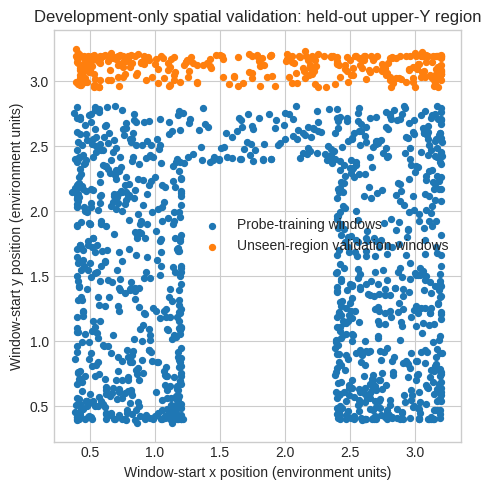

In [5]:
episode_train, episode_validation, episode_test = episode_group_train_val_test_split(
    choices, validation_fraction=0.2, test_fraction=0.2, seed=SEED
)
development_idx = np.sort(np.concatenate([episode_train, episode_validation]))
anchor_position = targets["position"][:, 0]
spatial_train_local, spatial_validation_local, spatial_config = spatial_holdout_split(
    anchor_position[development_idx], axis=1, quantile=0.8, high=True, buffer_fraction=0.05
)
spatial_train = development_idx[spatial_train_local]
spatial_validation = development_idx[spatial_validation_local]
splits = {
    "episode_validation": (episode_train, episode_validation),
    "spatial_validation": (spatial_train, spatial_validation),
}
print({name: (len(train), len(test)) for name, (train, test) in splits.items()})
print("Spatial split:", spatial_config)

plt.figure(figsize=(6, 5))
plt.scatter(anchor_position[spatial_train, 0], anchor_position[spatial_train, 1], s=18, label="Probe-training windows")
plt.scatter(anchor_position[spatial_validation, 0], anchor_position[spatial_validation, 1], s=18, label="Unseen-region validation windows")
plt.legend(); plt.gca().set_aspect("equal"); plt.title("Development-only spatial validation: held-out upper-Y region")
plt.xlabel("Window-start x position (environment units)")
plt.ylabel("Window-start y position (environment units)")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "spatial_split.png", dpi=180); plt.show()

## 4. Fit every layer with controls

For each representation, the code calls `align_representation` to construct the correct feature/label pair without mixing windows. It flattens only the time rows belonging to the selected training or validation windows. `fit_probe` then standardizes the feature columns from the training set, fits a ridge-linear map, and applies that frozen map to validation rows. No gradients pass into DINO or the predictor.

For each fitted probe we record:

- validation $R^2$, RMSE, and a complete-window bootstrap interval;
- a shuffled-label null;
- a position-only baseline predicting the same target from XY;
- residual-motion readability after subtracting the component predictable from XY.

Interpret the controls together: a credible motion result should beat the shuffled-label 95th percentile, beat the position-only decoder, remain positive after removing the portion of the target predictable from XY, and survive the spatial-validation split. The residual score is especially important for raw per-frame DINO motion probes.

In [6]:
def evaluate_representation(name, rep, variable, mode, split_name, train_idx, test_idx):
    # Construct h_t, Δh_t, or Δ²h_t and align it with the matching physical label.
    features, labels, position_context = align_representation(rep, targets, variable, mode)
    # Fit only the linear readout; the cached world-model representation stays frozen.
    truth, prediction, _ = fit_probe(features, labels, train_idx, test_idx, RIDGE)
    scores = regression_scores(truth, prediction)
    truth_groups, prediction_groups = group_flat_predictions_by_window(
        features, labels, test_idx, truth, prediction
    )
    ci = trajectory_bootstrap_metric_ci(
        truth_groups, prediction_groups, "r2", repeats=300, seed=SEED
    )
    # Destroy feature/label pairing to estimate a finite-sample null distribution.
    shuffled = shuffled_label_score(
        features, labels, train_idx, test_idx, RIDGE, repeats=20, seed=SEED
    )
    # Test how much of the target can be predicted from maze XY alone.
    pos_truth, pos_prediction, _ = fit_probe(
        position_context, labels, train_idx, test_idx, RIDGE
    )
    # Remove the target component explained linearly by XY, then probe what remains.
    residual_labels = residualize_against_position(labels, position_context, train_idx, RIDGE)
    residual_truth, residual_prediction, _ = fit_probe(
        features, residual_labels, train_idx, test_idx, RIDGE
    )
    family, layer, kind = name.split("/", 2)
    return {
        "representation": name, "family": family, "layer": int(layer), "kind": kind,
        "variable": variable, "mode": mode, "split": split_name,
        **scores, "ci_low": ci[0], "ci_high": ci[1],
        "shuffled_q95": float(np.quantile(shuffled, 0.95)),
        "position_only_r2": regression_scores(pos_truth, pos_prediction)["r2"],
        "position_residual_r2": regression_scores(residual_truth, residual_prediction)["r2"],
    }

rows = []
for split_name, (train_idx, test_idx) in splits.items():
    for name, rep in sorted(representations.items()):
        family = name.split("/", 1)[0]
        specs = [("position", "frame")]
        if family == "dino":
            specs += [("velocity", "frame"), ("velocity", "delta")]
            if rep.shape[1] >= 3:
                specs += [("acceleration", "frame"), ("acceleration", "second_delta")]
        else:
            specs += [("velocity", "frame"), ("acceleration", "frame")]
        for variable, mode in specs:
            rows.append(evaluate_representation(
                name, rep, variable, mode, split_name, train_idx, test_idx
            ))

metrics = rows
write_rows(OUTPUT_DIR / "layerwise_cartesian_metrics.csv", metrics)
show_rows(metrics, limit=8)

representation        | family | layer | kind           | variable     | mode         | split              | r2                   | rmse                 | mae                  | ci_low               | ci_high              | shuffled_q95          | position_only_r2       | position_residual_r2 
----------------------+--------+-------+----------------+--------------+--------------+--------------------+----------------------+----------------------+----------------------+----------------------+----------------------+-----------------------+------------------------+----------------------
dino/0/cls            | dino   | 0     | cls            | position     | frame        | episode_validation | 0.8867625743762396   | 0.33536250463631817  | 0.26060837879840754  | 0.8798123493710774   | 0.8931900820441174   | 0.004603129195405381  | 0.9999956765773601     | 0.886136694394923    
dino/0/cls            | dino   | 0     | cls            | velocity     | frame        | episode_validation | -0.034

## 5. Where each Cartesian variable becomes readable

The primary DINO curves use a raw frame for position, a first temporal difference for velocity, and a second temporal difference for acceleration. Predictor curves use contextual per-slot features. DINO and predictor results are plotted in separate figures because their block counts and semantics differ. The horizontal axis is the transformer-block index; the vertical axis is validation $R^2$. $R^2=1$ is perfect prediction, $R^2=0$ is no better than predicting the validation mean, and negative values are worse than that baseline. Shaded regions are 95% percentile intervals obtained by resampling complete validation trajectory windows. Compare curves within a panel; do not treat raw $R^2$ values for different targets as equally difficult tasks.


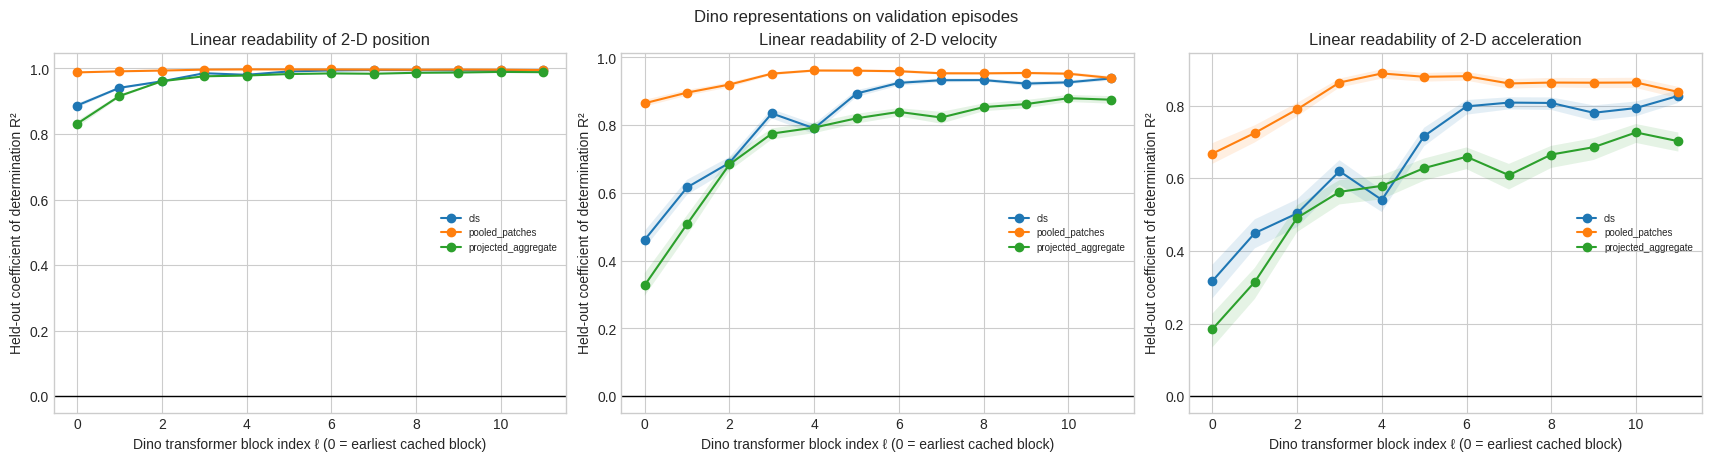

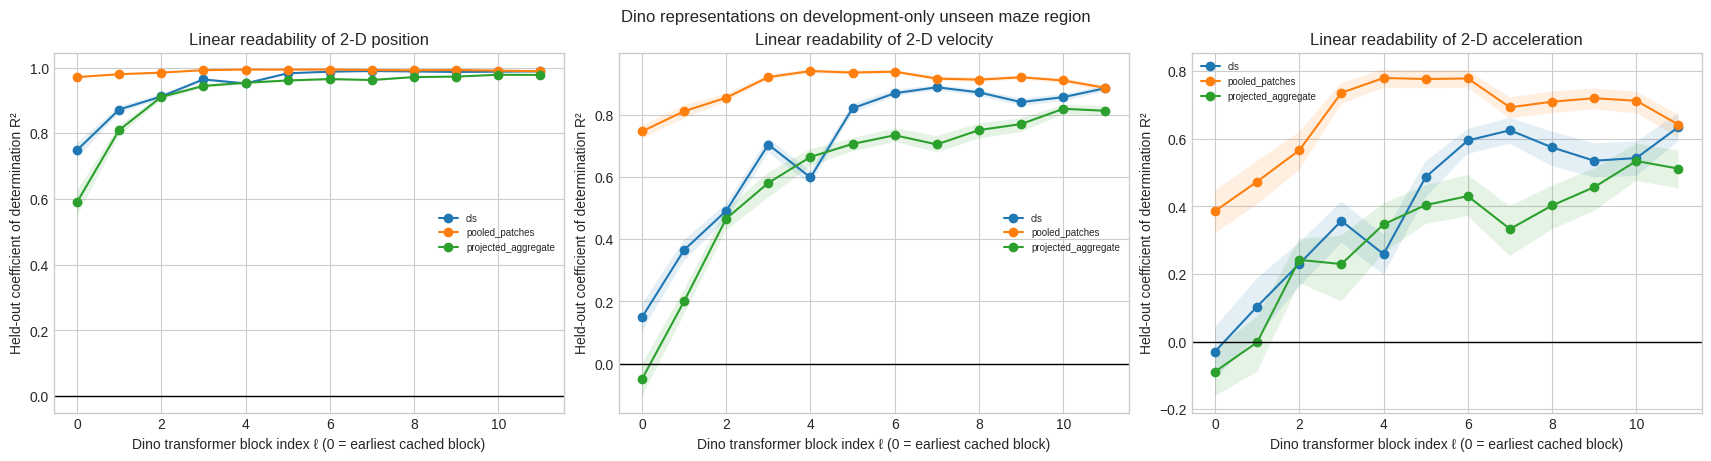

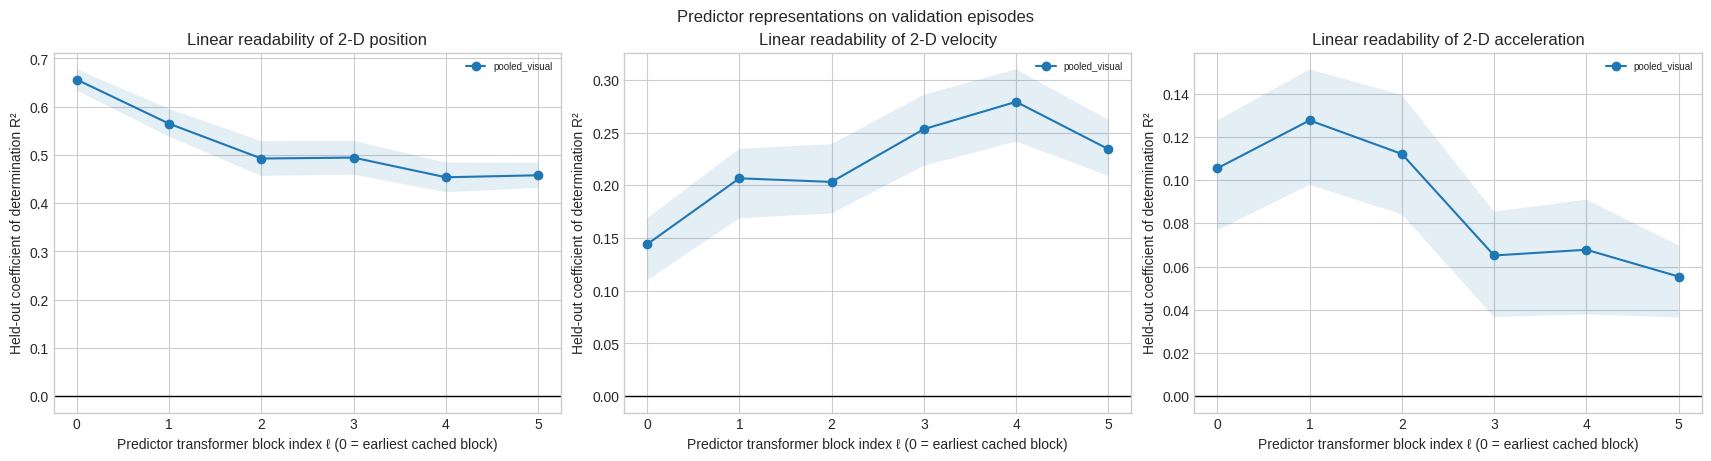

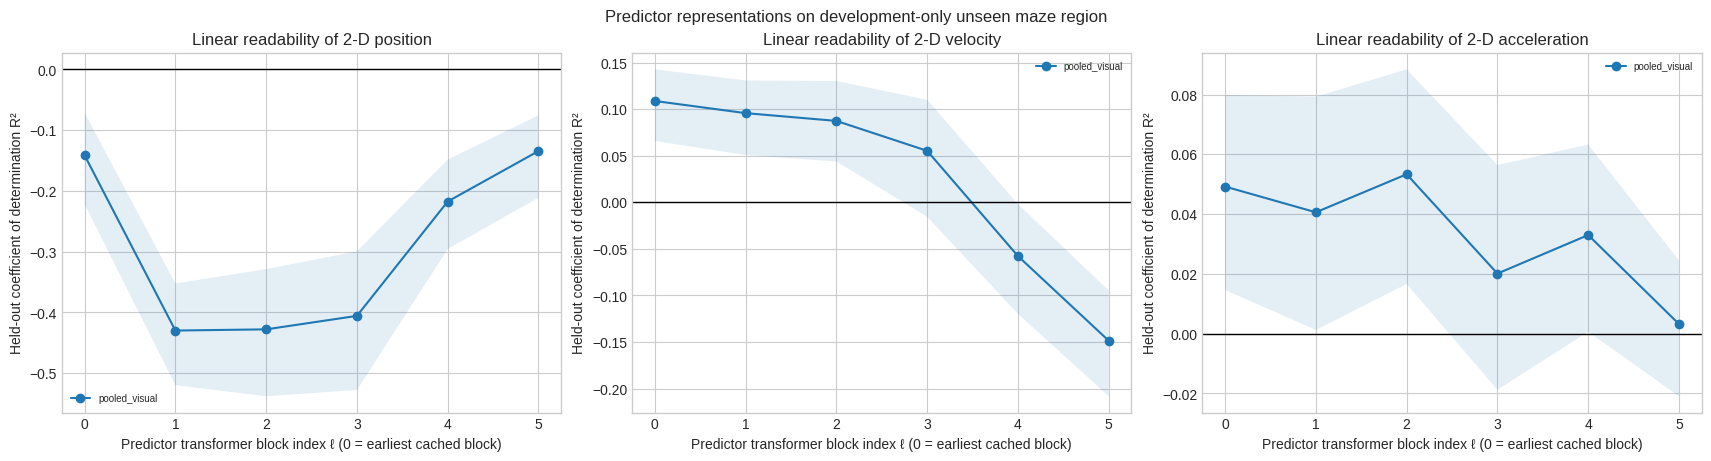

In [7]:
def primary_mode(family, variable):
    if family == "predictor" or variable == "position":
        return "frame"
    return {"velocity": "delta", "acceleration": "second_delta"}[variable]

def plot_layer_curves(frame, family, split, filename):
    family_rows = [row for row in frame if row["family"] == family]
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
    for ax, variable in zip(axes, ["position", "velocity", "acceleration"]):
        candidates = [
            row for row in family_rows
            if row["split"] == split and row["variable"] == variable
        ]
        for (kind,), group in grouped(candidates, ["kind"]).items():
            group = sorted(
                [row for row in group if row["mode"] == primary_mode(family, variable)],
                key=lambda row: row["layer"],
            )
            if not group:
                continue
            layer = np.asarray([row["layer"] for row in group])
            ax.plot(layer, [row["r2"] for row in group], marker="o", label=kind)
            ax.fill_between(
                layer,
                [row["ci_low"] for row in group],
                [row["ci_high"] for row in group],
                alpha=0.12,
            )
        ax.axhline(0, color="black", lw=1)
        ax.set(
            title=f"Linear readability of 2-D {variable}",
            xlabel=f"{family.title()} transformer block index ℓ (0 = earliest cached block)",
            ylabel="Held-out coefficient of determination R²",
        )
        ax.legend(fontsize=7)
    split_title = "validation episodes" if split == "episode_validation" else "development-only unseen maze region"
    fig.suptitle(f"{family.title()} representations on {split_title}")
    fig.savefig(OUTPUT_DIR / filename, dpi=180)
    plt.show()

for family in ("dino", "predictor"):
    plot_layer_curves(
        metrics,
        family=family,
        split="episode_validation",
        filename=f"readability_by_{family}_layer.png",
    )
    plot_layer_curves(
        metrics,
        family=family,
        split="spatial_validation",
        filename=f"readability_by_{family}_layer_spatial_validation.png",
    )


## 6. Is DINO motion static or genuinely temporal?

This is the core shortcut check. `frame` asks a linear probe to infer motion from one frozen DINO frame feature, even though DINO itself has no temporal input. `delta` supplies $h_{t+1}-h_t$ for velocity, and `second_delta` supplies $h_{t+2}-2h_{t+1}+h_t$ for acceleration. A high raw-frame score that disappears on the spatial-validation split can be explained by location. A temporal-difference score that beats the position-only baseline and survives in unseen regions is stronger evidence that **change in representation space tracks physical motion**.

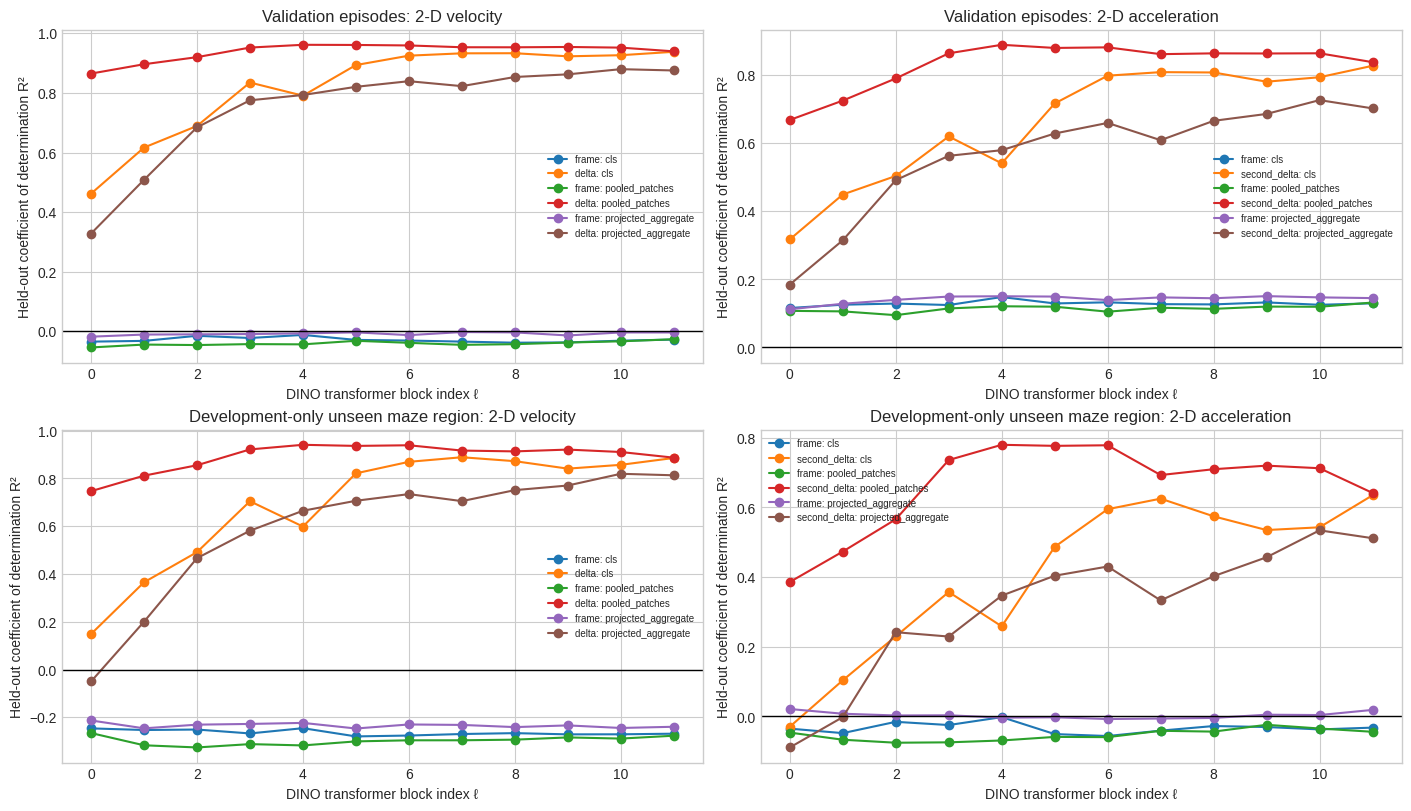

split              | variable | representation         | r2                 | position_only_r2      | position_residual_r2 | shuffled_q95         
-------------------+----------+------------------------+--------------------+-----------------------+----------------------+----------------------
episode_validation | velocity | dino/4/pooled_patches  | 0.961448107393072  | -0.004288917957066651 | 0.9603244130037752   | -0.03613669044857676 
episode_validation | velocity | dino/5/pooled_patches  | 0.9609292926194368 | -0.004288917957066651 | 0.9598794416706611   | -0.025327988896468832
episode_validation | velocity | dino/6/pooled_patches  | 0.9592743894555448 | -0.004288917957066651 | 0.9580818902656929   | -0.035689115702384915
episode_validation | velocity | dino/9/pooled_patches  | 0.9541685152041885 | -0.004288917957066651 | 0.9528210693553983   | -0.01404331878960055 
episode_validation | velocity | dino/7/pooled_patches  | 0.9532346246533626 | -0.004288917957066651 | 0.95197808577877

In [8]:
dino_motion = [
    row for row in metrics
    if row["family"] == "dino" and row["variable"] in ("velocity", "acceleration")
]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
for ax, split_name, variable in zip(
    axes.flat,
    ["episode_validation", "episode_validation", "spatial_validation", "spatial_validation"],
    ["velocity", "acceleration", "velocity", "acceleration"],
):
    candidates = [row for row in dino_motion if row["split"] == split_name and row["variable"] == variable]
    for (mode, kind), group in grouped(candidates, ["mode", "kind"]).items():
        group = sorted(group, key=lambda row: row["layer"])
        ax.plot(
            [row["layer"] for row in group], [row["r2"] for row in group],
            marker="o", label=f"{mode}: {kind}",
        )
    ax.axhline(0, color="black", lw=1)
    split_title = {
        "episode_validation": "Validation episodes",
        "spatial_validation": "Development-only unseen maze region",
    }[split_name]
    ax.set(
        title=f"{split_title}: 2-D {variable}",
        xlabel="DINO transformer block index ℓ",
        ylabel="Held-out coefficient of determination R²",
    )
    ax.legend(fontsize=7)
fig.savefig(OUTPUT_DIR / "static_vs_temporal_dino.png", dpi=180); plt.show()

control_view = sorted(
    [row for row in dino_motion if row["mode"] in ("delta", "second_delta")],
    key=lambda row: row["r2"], reverse=True,
)
show_rows(control_view, [
    "split", "variable", "representation", "r2", "position_only_r2",
    "position_residual_r2", "shuffled_q95"
], 20)

## 7. Cartesian versus polar motion

The Cartesian probe predicts $(v_x,v_y)$ or $(a_x,a_y)$ directly. The polar probes factor the same vectors into magnitude and direction: speed $\lVert v\rVert$, heading $(\cos\theta_v,\sin\theta_v)$, acceleration magnitude $\lVert a\rVert$, and acceleration direction $(\cos\theta_a,\sin\theta_a)$. Magnitude is evaluated with $R^2$; direction is evaluated with mean cosine similarity, where 1 means aligned, 0 means unrelated or orthogonal on average, and -1 means opposite. Direction metrics exclude the slowest 10% of samples because angle is unstable when magnitude is nearly zero. DINO and predictor results are written to separate figures.


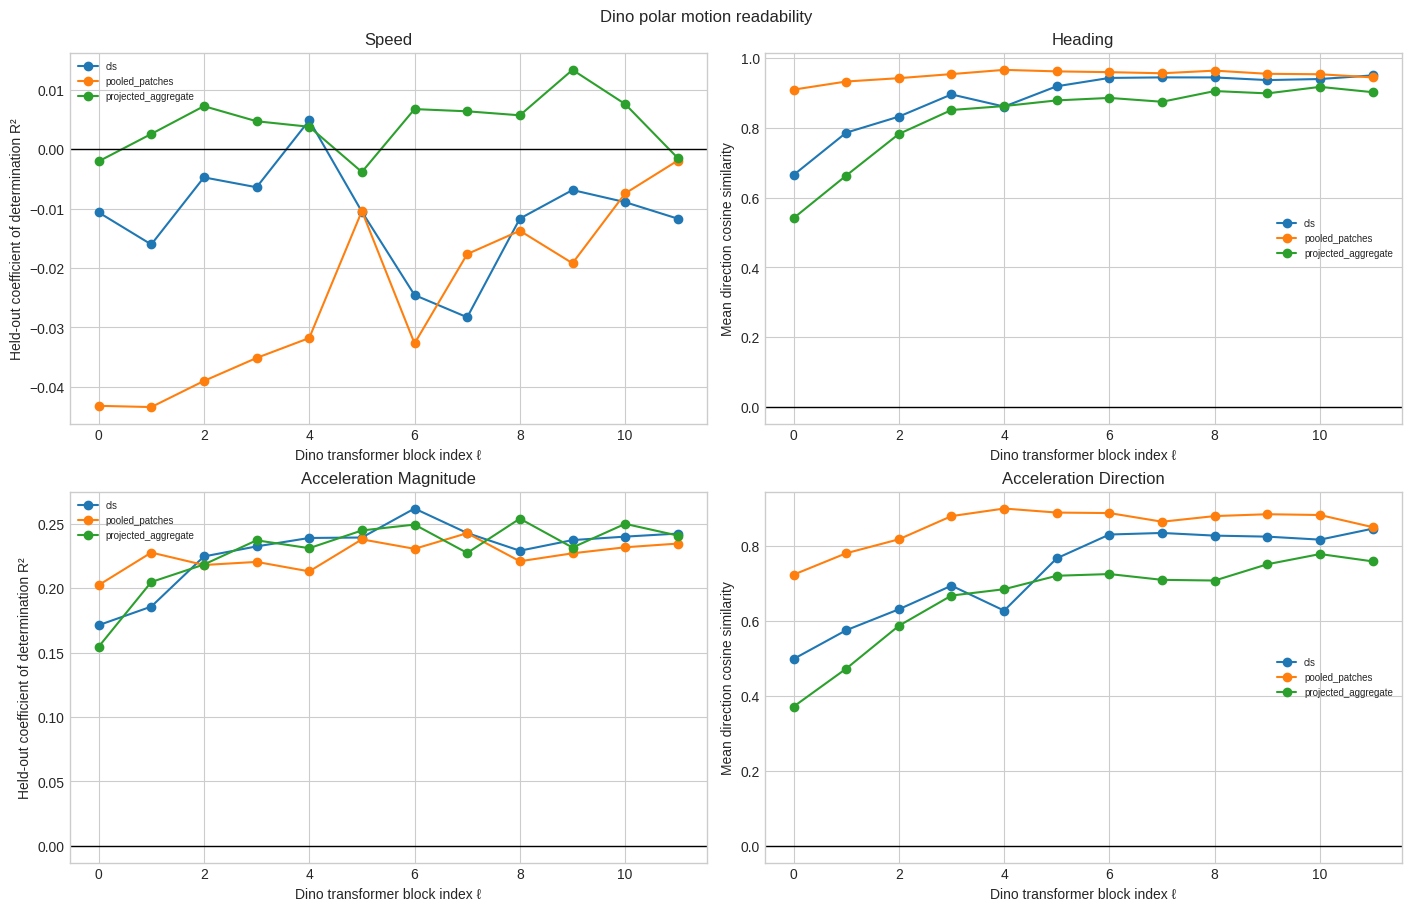

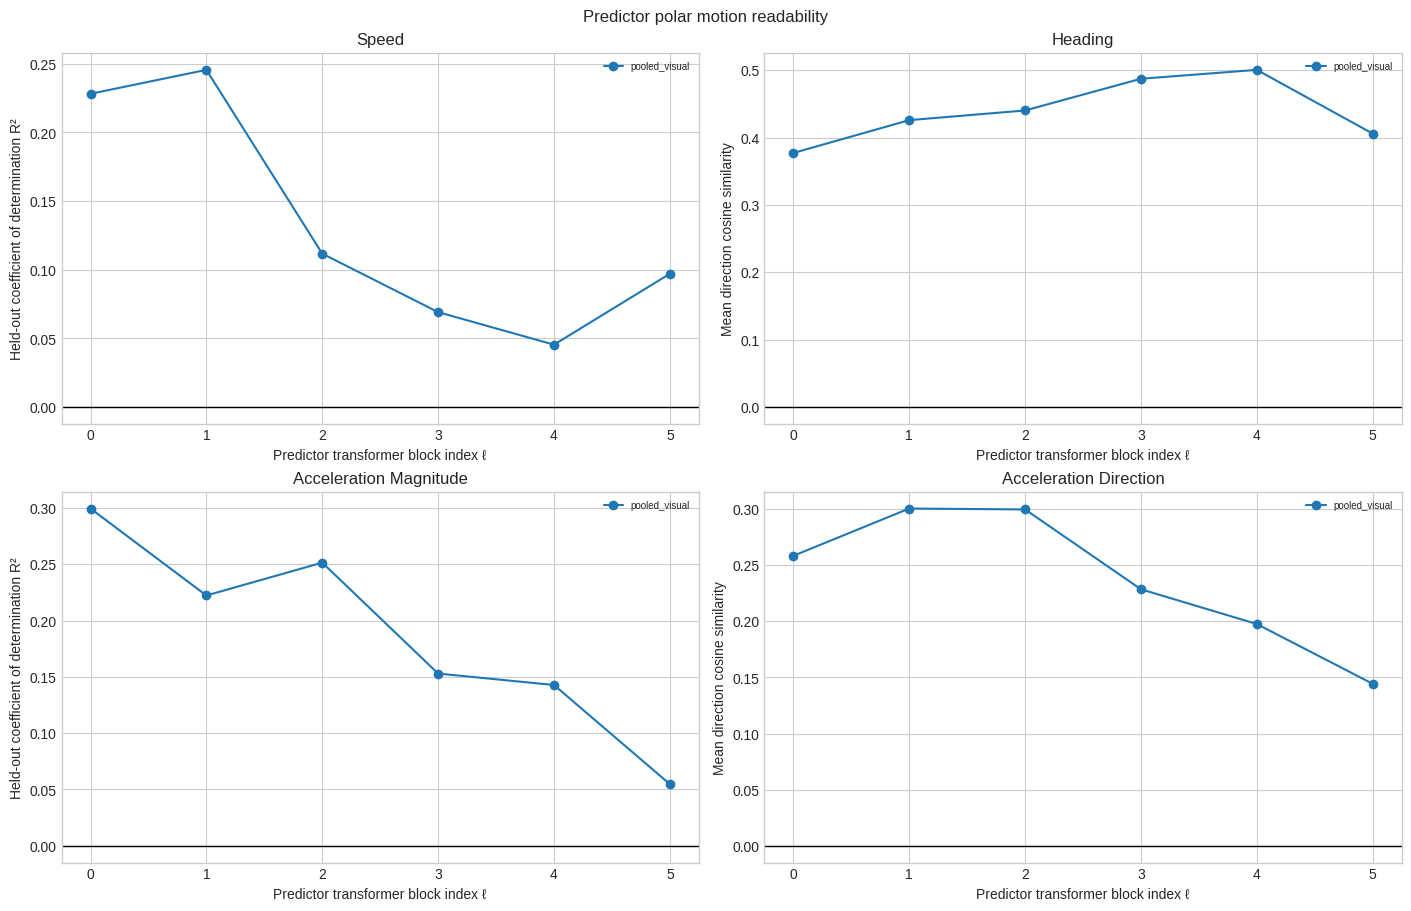

In [9]:
polar_rows = []
train_idx, test_idx = splits["episode_validation"]
for name, rep in sorted(representations.items()):
    family, layer, kind = name.split("/", 2)
    velocity_mode = "delta" if family == "dino" else "frame"
    acceleration_mode = "second_delta" if family == "dino" else "frame"
    for variable, mode in [
        ("speed", velocity_mode), ("heading", velocity_mode),
        ("acceleration_magnitude", acceleration_mode),
        ("acceleration_direction", acceleration_mode),
    ]:
        if mode == "second_delta" and rep.shape[1] < 3:
            continue
        features, labels, _ = align_representation(rep, targets, variable, mode)
        if variable in ("heading", "acceleration_direction"):
            magnitude_variable = "speed" if variable == "heading" else "acceleration_magnitude"
            _, magnitude, _ = align_representation(rep, targets, magnitude_variable, mode)
            labels, cutoff = mask_slow_directions(labels, magnitude, train_idx, quantile=0.1)
        truth, prediction, _ = fit_probe(features, labels, train_idx, test_idx, RIDGE)
        is_direction = "direction" in variable or variable == "heading"
        score = direction_scores(truth, prediction) if is_direction else regression_scores(truth, prediction)
        truth_groups, prediction_groups = group_flat_predictions_by_window(
            features, labels, test_idx, truth, prediction
        )
        ci = trajectory_bootstrap_metric_ci(
            truth_groups, prediction_groups, "cosine" if is_direction else "r2",
            repeats=300, seed=SEED,
        )
        polar_rows.append({
            "representation": name, "family": family, "layer": int(layer), "kind": kind,
            "variable": variable, "mode": mode, **score,
            "ci_low": ci[0], "ci_high": ci[1],
        })

polar_metrics = polar_rows
write_rows(OUTPUT_DIR / "layerwise_polar_metrics.csv", polar_metrics)

def plot_polar_family(family, filename):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    for ax, (variable, score_key) in zip(axes.flat, [
        ("speed", "r2"), ("heading", "cosine"),
        ("acceleration_magnitude", "r2"), ("acceleration_direction", "cosine"),
    ]):
        subset = [
            row for row in polar_metrics
            if row["family"] == family and row["variable"] == variable
        ]
        for (kind,), group in grouped(subset, ["kind"]).items():
            group = sorted(group, key=lambda row: row["layer"])
            ax.plot(
                [row["layer"] for row in group], [row[score_key] for row in group],
                marker="o", label=kind,
            )
        ax.axhline(0, color="black", lw=1)
        metric_label = (
            "Held-out coefficient of determination R²"
            if score_key == "r2" else "Mean direction cosine similarity"
        )
        ax.set(
            title=variable.replace("_", " ").title(),
            xlabel=f"{family.title()} transformer block index ℓ",
            ylabel=metric_label,
        )
        ax.legend(fontsize=7)
    fig.suptitle(f"{family.title()} polar motion readability")
    fig.savefig(OUTPUT_DIR / filename, dpi=180)
    plt.show()

plot_polar_family("dino", "cartesian_vs_polar_dino_by_layer.png")
plot_polar_family("predictor", "cartesian_vs_polar_predictor_by_layer.png")


## 8. Emergence table

A conservative onset is the first of two consecutive layers whose $R^2$ exceeds the shuffled-label 95th percentile and reaches at least half of that representation family's peak score. This definition should be reported alongside the full curves rather than treated as a uniquely correct boundary.

In [10]:
onsets = []
primary = [
    row for row in metrics
    if row["split"] == "episode_validation"
    and row["mode"] == primary_mode(row["family"], row["variable"])
]
for (family, kind, variable), group in grouped(primary, ["family", "kind", "variable"]).items():
    best = max(group, key=lambda row: row["r2"])
    onsets.append({
        "family": family, "kind": kind, "variable": variable,
        "onset_layer": readability_onset(
            group, "r2", "shuffled_q95", consecutive=2, fraction_of_peak=0.5
        ),
        "peak_r2": best["r2"], "peak_layer": int(best["layer"]),
    })
write_rows(OUTPUT_DIR / "readability_onsets.csv", onsets)
show_rows(sorted(onsets, key=lambda row: (row["variable"], row["family"], row["kind"])))

family    | kind                | variable     | onset_layer | peak_r2             | peak_layer
----------+---------------------+--------------+-------------+---------------------+-----------
dino      | cls                 | acceleration | 1           | 0.827000756058317   | 11        
dino      | pooled_patches      | acceleration | 0           | 0.8886446459690307  | 4         
dino      | projected_aggregate | acceleration | 2           | 0.7262287045168963  | 10        
predictor | pooled_visual       | acceleration | 0           | 0.12762392926542332 | 1         
dino      | cls                 | position     | 0           | 0.994872736475846   | 7         
dino      | pooled_patches      | position     | 0           | 0.996890787050424   | 4         
dino      | projected_aggregate | position     | 0           | 0.989223621119307   | 10        
predictor | pooled_visual       | position     | 0           | 0.6559231204550846  | 0         
dino      | cls                 | veloci

## 9. Interpretation checklist

Each point on a layer curve answers: **if the world model is frozen at this layer, how accurately can one ridge-linear map recover this physical target on examples withheld from probe training?** The plotted score evaluates the linear map, not the world model's image-prediction loss.

Read the outputs in this order:

1. Use *dataset_motion_overview.png* and *speed_by_position.png* to understand the target distribution and the risk that location predicts motion.
2. Compare *readability_by_dino_layer.png* with *readability_by_predictor_layer.png* to locate peaks without treating predictor blocks as extra DINO layers.
3. Use *static_vs_temporal_dino.png* to ask whether DINO motion comes from a single image or from feature change across images.
4. Use the two family-specific spatial-holdout figures to test whether the decoder transfers to a maze region absent from probe training.
5. Compare the DINO and predictor polar figures to see whether vector components or magnitude/direction are more linearly organized.

Use these rules when writing the result:

1. **Position:** a high per-frame DINO score is expected and validates the probe pipeline.
2. **Velocity:** prioritize DINO $\Delta h$ and contextual predictor scores. Treat raw-frame DINO velocity as a shortcut diagnostic.
3. **Acceleration:** prioritize DINO $\Delta^2h$ and contextual predictor scores; compare its onset with velocity.
4. **Location generalization:** report whether motion performance survives the spatial holdout and beats the position-only baseline.
5. **Representation kind:** a pooled-patch result means information is distributed across the spatial token field; a CLS result means it is available from the global token; a projected-aggregate result means it survives the model's projection/aggregation stage.
6. **Causality:** never infer causal use from readability alone. Interventions or steering along probe directions are a separate experiment.

The strongest defensible claim has the form: "Using feature construction F from representation K, variable X becomes linearly readable at layer L, beats shuffled and position-only controls, remains readable after position residualization, and generalizes to a held-out maze region."


In [11]:
summary = {
    "config": {
        **cache_metadata, "ridge": RIDGE, "step_dt": STEP_DT,
        "episode_split": {"train_windows": len(episode_train), "validation_windows": len(episode_validation), "locked_test_windows": len(episode_test)},
        "spatial_split": spatial_config,
    },
    "onsets": onsets,
    "best_cartesian_rows": sorted(metrics, key=lambda row: row["r2"], reverse=True)[:20],
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, default=str))
print("Wrote:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)

Wrote:
 - activation_cache_2000_off_paper_lr1e6_6f864080.npz
 - cartesian_vs_polar_dino_by_layer.png
 - cartesian_vs_polar_predictor_by_layer.png
 - dataset_motion_overview.png
 - layerwise_cartesian_metrics.csv
 - layerwise_polar_metrics.csv
 - readability_by_dino_layer.png
 - readability_by_dino_layer_spatial_validation.png
 - readability_by_predictor_layer.png
 - readability_by_predictor_layer_spatial_validation.png
 - readability_onsets.csv
 - spatial_split.png
 - speed_by_position.png
 - static_vs_temporal_dino.png
 - summary.json


## 10. Paper-protocol straightening comparison across all 2,000 trajectories

The main walkthrough above uses the paper-matched straightening-OFF checkpoint (seed 0, encoder/projector learning rate `1e-6`) on one deterministic window from each of the 2,000 OSF trajectories. This section keeps that exact sample fixed, reuses its OFF activations and labels, and collects straightening-ON activations from the `aggcos1e-1` checkpoint trained with learning rate `1e-5`.

Both models use the same environment data, seed, architecture, 20-epoch schedule, trajectory windows, labels, splits, representations, ridge probes, controls, and metrics. Their straightening settings and encoder/projector learning rates differ exactly as reported by the paper. Therefore, this is a faithful comparison of the paper's two configurations, but it is not a causal ablation of straightening alone.

The downloaded ON archive contains model weights but no Hydra file. To make the run auditable, the checkpoint-loading cell writes `umaze_paper_on_reconstructed_hydra.yaml` from the paper's Appendix A.2/B.2 and the released `conf/train.yaml`. This sidecar is explicitly marked as a reconstruction; it is not presented as the missing original file.


In [12]:
# Assets, the OSF dataset, all 2,000 window identifiers, and OFF activations
# were prepared in Section 1. Verify that the canonical sample is still active.
assert len(choices) == MAX_WINDOWS == MAX_TRAJECTORIES == 2000
assert len(set(np.asarray(choices)[:, 0])) == MAX_TRAJECTORIES
assert set(MATCHED_CHECKPOINTS) == {"off", "on"}
assert MATCHED_DATA_ARCHIVE.exists()
print({
    "complete_trajectories": len(set(np.asarray(choices)[:, 0])),
    "windows": len(choices),
    "unique_episodes": len(set(np.asarray(choices)[:, 0])),
    "off_checkpoint": str(MATCHED_CHECKPOINTS["off"]),
    "on_checkpoint": str(MATCHED_CHECKPOINTS["on"]),
    "off_encoder_lr": MATCHED_ASSETS["off"]["encoder_lr"],
    "on_encoder_lr": MATCHED_ASSETS["on"]["encoder_lr"],
    "on_config_path": MATCHED_ASSETS["on"]["config_path"],
    "on_config_provenance": MATCHED_ASSETS["on"]["config_provenance"],
})


{'complete_trajectories': 2000, 'windows': 2000, 'unique_episodes': 2000, 'off_checkpoint': '/content/probing-VLMs/artifacts/checkpoints/umaze_paper_protocol_on_off/off/model_20.pth', 'on_checkpoint': '/content/probing-VLMs/artifacts/checkpoints/umaze_paper_protocol_on_off/on/model_20.pth', 'off_encoder_lr': 1e-06, 'on_encoder_lr': 1e-05, 'on_config_path': '/content/probing-VLMs/artifacts/checkpoints/umaze_paper_protocol_on_off/on/hydra.yaml', 'on_config_provenance': 'reconstructed sidecar; see checkpoint README'}


### Reuse all 2,000 canonical trajectory windows and collect ON activations

No new windows are sampled here. `matched_choices` is a direct copy of the one-window-per-trajectory sample used by every preceding graph and probe. The OFF side reuses the already-loaded activations, states, and actions; only the ON checkpoint requires another forward pass.


In [13]:
MATCHED_OUTPUT_DIR = Path("/content/umaze_matched_probe_results")
MATCHED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
matched_choices = np.asarray(choices).copy()
assert matched_choices.shape == (MAX_TRAJECTORIES, 2)
assert len(set(matched_choices[:, 0])) == MAX_TRAJECTORIES

matched_representations = {"off": representations}
matched_states_by_condition = {"off": states}
matched_actions_by_condition = {"off": actions}

on_cache_path = MATCHED_OUTPUT_DIR / f"activation_cache_{MAX_TRAJECTORIES}_on.npz"
on_cache_is_valid = False
if on_cache_path.exists():
    on_reps, on_states, on_actions, on_choices, _ = load_activation_cache(on_cache_path)
    on_cache_is_valid = np.array_equal(on_choices, matched_choices)
    if not on_cache_is_valid:
        print(f"Ignoring stale ON cache with non-matching windows: {on_cache_path}")

if not on_cache_is_valid:
    modules = load_checkpoint(MATCHED_CHECKPOINTS["on"], torch.device(DEVICE))
    on_reps, on_states, on_actions = collect_activations(
        modules,
        dataset,
        matched_choices,
        BATCH_SIZE,
        FRAME_SKIP,
        NUM_FRAMES,
        torch.device(DEVICE),
        include_kinds={"cls", "pooled_patches", "projected_aggregate", "pooled_visual"},
    )
    on_choices = matched_choices.copy()
    metadata = {
        "condition": "on",
        "checkpoint": str(MATCHED_CHECKPOINTS["on"]),
        "straighten": MATCHED_ASSETS["on"]["straighten"],
        "encoder_lr": MATCHED_ASSETS["on"]["encoder_lr"],
        "checkpoint_sha256": MATCHED_ASSETS["on"]["checkpoint_sha256"],
        "seed": SEED,
        "num_windows": len(matched_choices),
        "frameskip": FRAME_SKIP,
        "num_frames": NUM_FRAMES,
    }
    save_activation_cache(
        on_cache_path, on_reps, on_states, on_actions, on_choices, metadata,
    )
    del modules
    torch.cuda.empty_cache()

assert np.array_equal(on_choices, matched_choices)
matched_representations["on"] = on_reps
matched_states_by_condition["on"] = on_states
matched_actions_by_condition["on"] = on_actions

assert set(matched_representations["off"]) == set(matched_representations["on"])
assert np.array_equal(matched_states_by_condition["off"], matched_states_by_condition["on"])
assert np.array_equal(matched_actions_by_condition["off"], matched_actions_by_condition["on"])

matched_states = matched_states_by_condition["off"]
matched_actions = matched_actions_by_condition["off"]
matched_targets = build_motion_targets(matched_states, FRAME_SKIP, STEP_DT)

matched_episode_train, matched_episode_validation, matched_episode_test = episode_group_train_val_test_split(
    matched_choices, validation_fraction=0.2, test_fraction=0.2, seed=SEED
)
matched_development_idx = np.sort(np.concatenate([matched_episode_train, matched_episode_validation]))
matched_anchor_position = matched_targets["position"][:, 0]
matched_spatial_train_local, matched_spatial_validation_local, matched_spatial_config = spatial_holdout_split(
    matched_anchor_position[matched_development_idx], axis=1, quantile=0.8, high=True, buffer_fraction=0.05
)
matched_spatial_train = matched_development_idx[matched_spatial_train_local]
matched_spatial_validation = matched_development_idx[matched_spatial_validation_local]
matched_splits = {
    "episode_validation": (matched_episode_train, matched_episode_validation),
    "spatial_validation": (matched_spatial_train, matched_spatial_validation),
}

assert np.array_equal(matched_episode_train, episode_train)
assert np.array_equal(matched_episode_validation, episode_validation)
assert np.array_equal(matched_episode_test, episode_test)
assert np.array_equal(matched_spatial_train, spatial_train)
assert np.array_equal(matched_spatial_validation, spatial_validation)
print("Verified that every section uses one matched window from each of all 2,000 trajectories.")
print({name: (len(train), len(test)) for name, (train, test) in matched_splits.items()})


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_81b2b6419385


Verified that every section uses one matched window from each of all 2,000 trajectories.
{'episode_validation': (1200, 400), 'spatial_validation': (1175, 320)}


### Run the same layerwise probes

This calls the existing `evaluate_representation` function without changing it. Each checkpoint gets the same OSF targets, episode-validation split, spatial-validation split, ridge value, shuffled-label control, position-only control, position residualization, and complete-window bootstrap count.

In [14]:
matched_rows = []
original_targets = targets
targets = matched_targets
try:
    for condition in ("off", "on"):
        for split_name, (train_idx, test_idx) in matched_splits.items():
            for name, rep in sorted(matched_representations[condition].items()):
                family = name.split("/", 1)[0]
                specs = [("position", "frame")]
                if family == "dino":
                    specs += [("velocity", "frame"), ("velocity", "delta")]
                    if rep.shape[1] >= 3:
                        specs += [("acceleration", "frame"), ("acceleration", "second_delta")]
                else:
                    specs += [("velocity", "frame"), ("acceleration", "frame")]

                for variable, mode in specs:
                    row = evaluate_representation(
                        name, rep, variable, mode, split_name, train_idx, test_idx
                    )
                    row["condition"] = condition
                    matched_rows.append(row)
finally:
    targets = original_targets

matched_metrics = matched_rows
write_rows(MATCHED_OUTPUT_DIR / "matched_layerwise_cartesian_metrics.csv", matched_metrics)
show_rows(matched_metrics, [
    "condition", "split", "variable", "mode", "representation", "r2",
    "position_only_r2", "position_residual_r2", "shuffled_q95",
], limit=12)

condition | split              | variable     | mode         | representation             | r2                   | position_only_r2       | position_residual_r2  | shuffled_q95         
----------+--------------------+--------------+--------------+----------------------------+----------------------+------------------------+-----------------------+----------------------
off       | episode_validation | position     | frame        | dino/0/cls                 | 0.8867625743762396   | 0.9999956765773601     | 0.886136694394923     | 0.004603129195405381 
off       | episode_validation | velocity     | frame        | dino/0/cls                 | -0.03474927812196826 | -0.0035581508967221787 | -0.034465766879033355 | -0.02726151591955199 
off       | episode_validation | velocity     | delta        | dino/0/cls                 | 0.46188224721461524  | -0.004288917957066651  | 0.46180679859179685   | -0.022698424891626354
off       | episode_validation | acceleration | frame        | dino/0/

### Overlay straightening OFF and ON

Dashed lines are the model trained without straightening. Solid lines are the matched straightened model. Each color keeps the representation type fixed. The top row uses unseen episodes. The bottom row uses the same unseen maze region used throughout this notebook. DINO and predictor comparisons are rendered as separate figures because the two modules have different depths and roles.


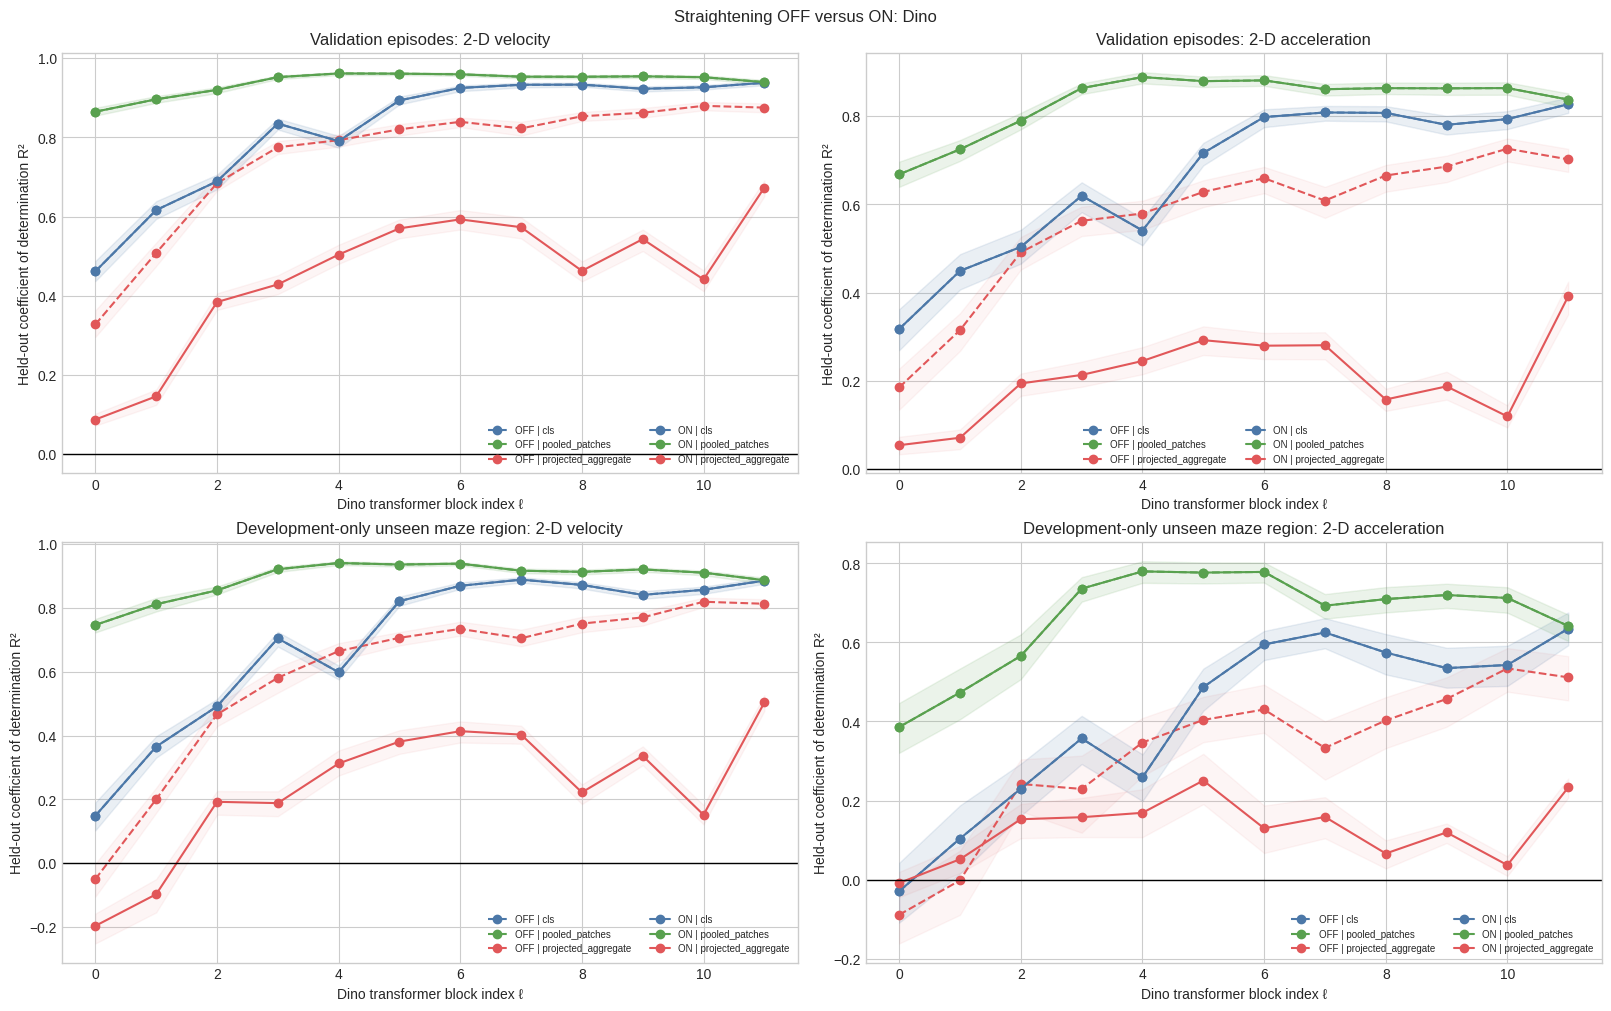

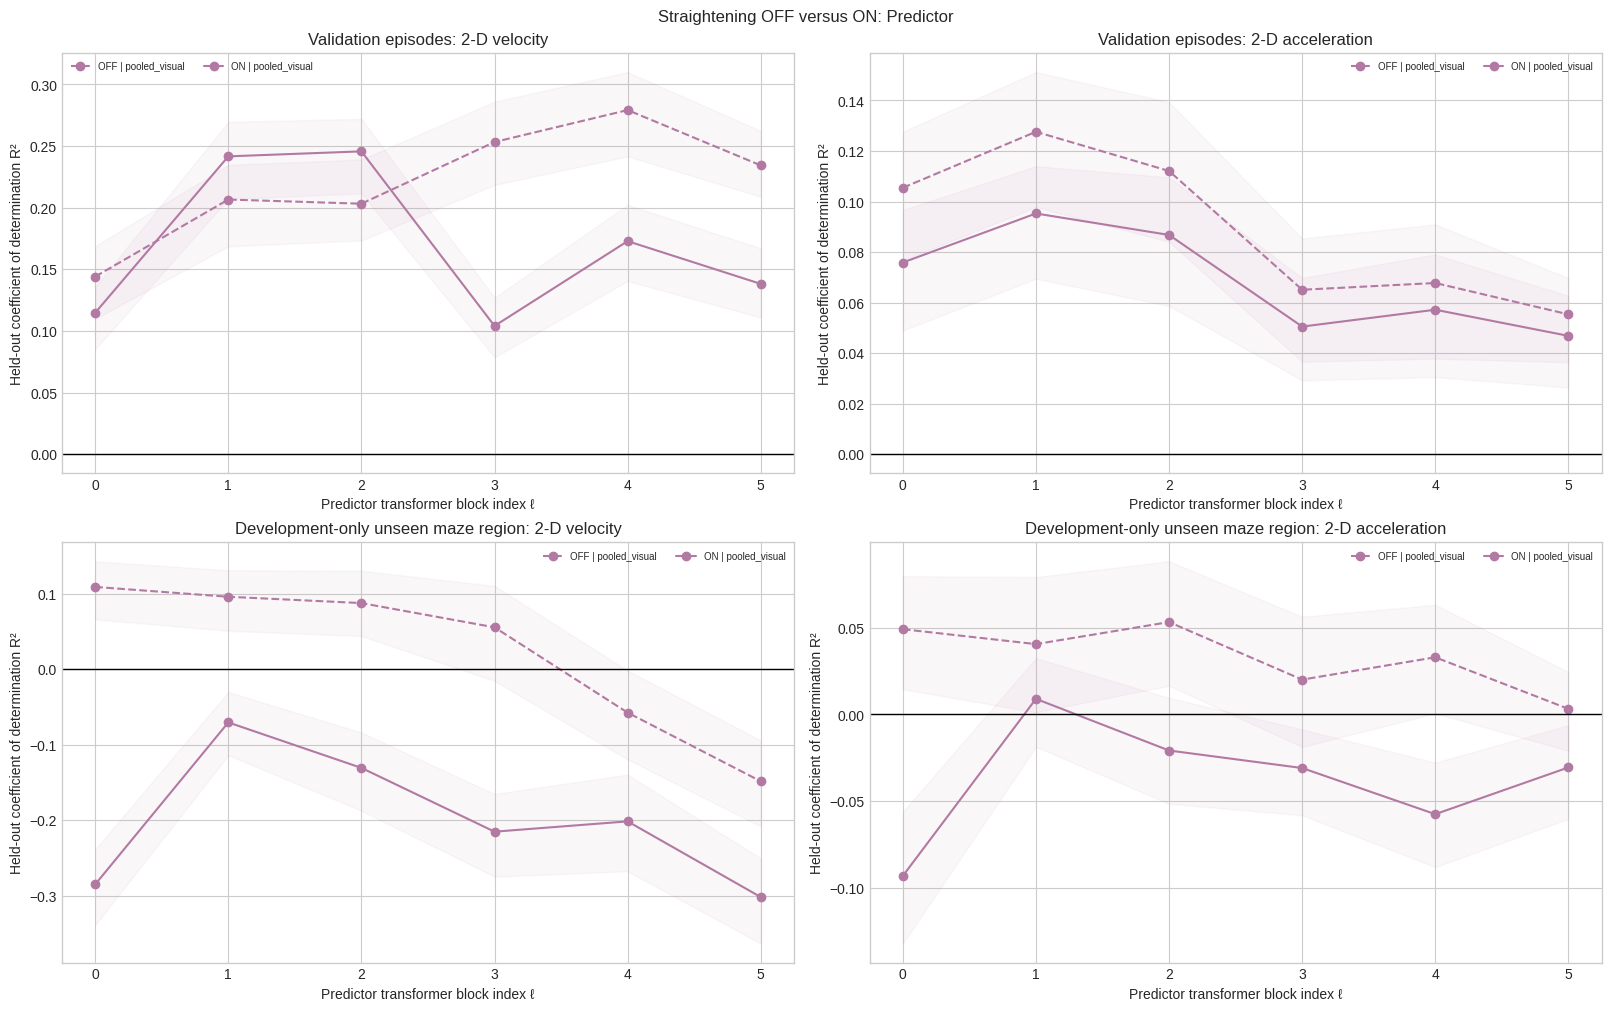

In [15]:
matched_colors = {
    "cls": "#4C78A8",
    "pooled_patches": "#59A14F",
    "projected_aggregate": "#E15759",
    "pooled_visual": "#B279A2",
}
matched_styles = {"off": "--", "on": "-"}

def plot_matched_family(family, filename):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    for ax, split_name, variable in zip(
        axes.flat,
        ["episode_validation", "episode_validation", "spatial_validation", "spatial_validation"],
        ["velocity", "acceleration", "velocity", "acceleration"],
    ):
        candidates = [
            row for row in matched_metrics
            if row["family"] == family
            and row["split"] == split_name
            and row["variable"] == variable
        ]
        for condition in ("off", "on"):
            condition_rows = [row for row in candidates if row["condition"] == condition]
            for (kind,), group in grouped(condition_rows, ["kind"]).items():
                group = sorted([
                    row for row in group
                    if row["mode"] == primary_mode(family, variable)
                ], key=lambda row: row["layer"])
                if not group:
                    continue
                layer = np.asarray([row["layer"] for row in group])
                ax.plot(
                    layer,
                    [row["r2"] for row in group],
                    marker="o",
                    color=matched_colors[kind],
                    linestyle=matched_styles[condition],
                    label=f"{condition.upper()} | {kind}",
                )
                ax.fill_between(
                    layer,
                    [row["ci_low"] for row in group],
                    [row["ci_high"] for row in group],
                    color=matched_colors[kind],
                    alpha=0.06,
                )
        ax.axhline(0, color="black", lw=1)
        split_title = {
            "episode_validation": "Validation episodes",
            "spatial_validation": "Development-only unseen maze region",
        }[split_name]
        ax.set(
            title=f"{split_title}: 2-D {variable}",
            xlabel=f"{family.title()} transformer block index ℓ",
            ylabel="Held-out coefficient of determination R²",
        )
        ax.legend(fontsize=7, ncol=2)
    fig.suptitle(f"Straightening OFF versus ON: {family.title()}")
    fig.savefig(MATCHED_OUTPUT_DIR / filename, dpi=180)
    plt.show()

plot_matched_family("dino", "straightening_off_vs_on_dino_by_layer.png")
plot_matched_family("predictor", "straightening_off_vs_on_predictor_by_layer.png")


### Read the comparison

Compare solid and dashed lines of the same color. A positive ON minus OFF difference means straightening made that variable more linearly readable at that layer. Check the shuffled, position-only, position-residualized, and spatial-validation values before treating a gap as motion information.

This remains a probe result. It measures linear readability and does not show that the planner causally uses the decoded direction.

In [16]:
paired_deltas = []
off_rows = [row for row in matched_metrics if row["condition"] == "off"]
on_rows = [row for row in matched_metrics if row["condition"] == "on"]

for off_row in off_rows:
    on_row = next(row for row in on_rows if all(
        row[key] == off_row[key]
        for key in ("representation", "variable", "mode", "split")
    ))
    paired_deltas.append({
        "split": off_row["split"],
        "variable": off_row["variable"],
        "mode": off_row["mode"],
        "representation": off_row["representation"],
        "off_r2": off_row["r2"],
        "on_r2": on_row["r2"],
        "on_minus_off_r2": on_row["r2"] - off_row["r2"],
    })

write_rows(MATCHED_OUTPUT_DIR / "straightening_on_minus_off.csv", paired_deltas)
motion_deltas = [
    row for row in paired_deltas
    if row["variable"] in ("velocity", "acceleration")
]
show_rows(
    sorted(motion_deltas, key=lambda row: abs(row["on_minus_off_r2"]), reverse=True),
    limit=30,
)

split              | variable     | mode         | representation              | off_r2              | on_r2                | on_minus_off_r2     
-------------------+--------------+--------------+-----------------------------+---------------------+----------------------+---------------------
spatial_validation | velocity     | delta        | dino/10/projected_aggregate | 0.8192391248945259  | 0.1514729573639524   | -0.6677661675305735 
episode_validation | acceleration | second_delta | dino/10/projected_aggregate | 0.7262287045168963  | 0.11890838936627335  | -0.6073203151506229 
spatial_validation | velocity     | delta        | dino/8/projected_aggregate  | 0.7508056525787131  | 0.22180660801170227  | -0.5289990445670109 
episode_validation | acceleration | second_delta | dino/8/projected_aggregate  | 0.6653934671060515  | 0.15734373131422486  | -0.5080497357918267 
episode_validation | acceleration | second_delta | dino/9/projected_aggregate  | 0.6856382689797902  | 0.1871175763484

## 11. Confirmatory trajectory-level evaluation

The layer curves above are exploratory and use training plus validation trajectories only. For each physical target and model family, this section selects one shared layer, readout, and temporal construction using mean validation $R^2$ across OFF and ON. It then refits that same selected probe separately for each condition on the combined training and validation trajectories and evaluates it once on the locked test trajectories.

Every headline $R^2$, RMSE, and MAE is accompanied by a 95% percentile interval from 1,000 bootstrap resamples of complete test trajectory windows. Frames within a window always remain together. OFF-minus-ON comparisons use the same resampled trajectory identities on both sides. The available checkpoints are currently model-training seed 0; bootstrap resampling does not replace independently trained model seeds.

In [17]:
HEADLINE_BOOTSTRAP_REPEATS = 1000
AVAILABLE_MODEL_SEEDS = [0]

def umaze_headline_specs(family, rep):
    specs = [("position", "frame")]
    if family == "dino":
        specs += [("velocity", "frame"), ("velocity", "delta")]
        if rep.shape[1] >= 3:
            specs += [("acceleration", "frame"), ("acceleration", "second_delta")]
    else:
        specs += [("velocity", "frame"), ("acceleration", "frame")]
    return specs

validation_selection, headline_metrics, headline_deltas = select_then_test_representations(
    matched_representations, matched_targets, align_representation,
    umaze_headline_specs, matched_episode_train, matched_episode_validation,
    matched_episode_test, ridge=RIDGE,
    bootstrap_repeats=HEADLINE_BOOTSTRAP_REPEATS, seed=SEED, model_seed=0,
)
write_rows(MATCHED_OUTPUT_DIR / "validation_selection_scores.csv", validation_selection)
write_rows(MATCHED_OUTPUT_DIR / "headline_selected_test_metrics.csv", headline_metrics)
write_rows(MATCHED_OUTPUT_DIR / "headline_straightening_deltas.csv", headline_deltas)
headline_protocol = {
    "model_training_seeds": AVAILABLE_MODEL_SEEDS,
    "split_windows": {"train": len(matched_episode_train), "validation": len(matched_episode_validation), "test": len(matched_episode_test)},
    "selection": "shared candidate maximizing mean OFF/ON validation R2 within family and target",
    "test_policy": "selected representation evaluated once after refitting on train+validation",
    "bootstrap": {"unit": "complete trajectory window", "repeats": HEADLINE_BOOTSTRAP_REPEATS, "interval": "95% percentile"},
}
(MATCHED_OUTPUT_DIR / "headline_protocol.json").write_text(json.dumps(headline_protocol, indent=2))
show_rows(headline_metrics, ["condition", "family", "variable", "representation", "mode", "r2", "r2_ci_low", "r2_ci_high", "rmse", "rmse_ci_low", "rmse_ci_high", "mae", "mae_ci_low", "mae_ci_high"], limit=20)
show_rows(headline_deltas, limit=20)


condition | family    | variable     | representation            | mode         | r2                  | r2_ci_low           | r2_ci_high          | rmse                 | rmse_ci_low          | rmse_ci_high         | mae                   | mae_ci_low            | mae_ci_high         
----------+-----------+--------------+---------------------------+--------------+---------------------+---------------------+---------------------+----------------------+----------------------+----------------------+-----------------------+-----------------------+---------------------
off       | dino      | acceleration | dino/4/pooled_patches     | second_delta | 0.8959962207353043  | 0.8818272571380973  | 0.9074304874023252  | 0.004791863780689808 | 0.004578411733939324 | 0.005011423621527163 | 0.0037698831253924325 | 0.0036041647254827906 | 0.003940742098370581
off       | dino      | position     | dino/4/pooled_patches     | frame        | 0.997196457926148   | 0.9969652664289123  | 0.99739778800201

#Raw Data
If you want to save the raw data, uncomment the cell below.

In [18]:
from pathlib import Path
import shutil
from google.colab import files

export_root = Path("/content/notebook_raw_export")
if export_root.exists():
    shutil.rmtree(export_root)
export_root.mkdir()

folders = {"results": Path(OUTPUT_DIR)}
if "MATCHED_OUTPUT_DIR" in globals():
    folders["matched_results"] = Path(MATCHED_OUTPUT_DIR)

for name, source in folders.items():
    if source.exists():
        shutil.copytree(source, export_root / name)

archive = shutil.make_archive(
    "/content/notebook_raw_export",
    "zip",
    export_root,
)
files.download(archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>